# Task 0: International Dividend-Based Valuation

The valuation model is estimated first for the international market portfolio and then for the individual developed-country portfolios.

## 1. Imports

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import shapiro
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

ROOT = Path("data")

## 2. International market data

In [2]:
price = pd.read_csv(ROOT / "intl-price.txt", sep=r"\s+")
total = pd.read_csv(ROOT / "intl-total.txt", sep=r"\s+")

market = pd.DataFrame({
    "Year": price.index.to_numpy(),
    "price_return": price["Mkt"].to_numpy() / 100,
    "total_return": total["Mkt"].to_numpy() / 100
})

print("Years:", market["Year"].iloc[0], "-", market["Year"].iloc[-1])
print("Observations:", len(market))

Years: 1975 - 2025
Observations: 51


## 3. Valuation variables

With $S_0=1$,

$$
S_t=S_{t-1}(1+R_t^P),
\qquad
D_t=S_{t-1}(R_t^T-R_t^P).
$$

The log total return and dividend growth are

$$
Q_t=\log(S_t+D_t)-\log(S_{t-1}),
\qquad
G_t=\log(D_t)-\log(D_{t-1}).
$$

In [3]:
S = []
S_prev = []
D = []

for i in range(len(market)):
    previous = 1.0 if i == 0 else S[-1]
    S_prev.append(previous)
    S.append(previous * (1 + market.loc[i, "price_return"]))
    D.append(previous * (market.loc[i, "total_return"] - market.loc[i, "price_return"]))

market["S_prev"] = S_prev
market["S"] = S
market["D"] = D

In [4]:
market["Q"] = np.log(market["S"] + market["D"]) - np.log(market["S_prev"])
market["G"] = np.log(market["D"]) - np.log(market["D"].shift(1))
market["Y"] = market["Q"] - market["G"]

model_data = market.dropna(subset=["Y"]).copy()
model_data["C"] = model_data["Y"].cumsum()
model_data["C_lag"] = model_data["C"].shift(1)
model_data = model_data.dropna(subset=["C_lag"]).copy()
model_data["t"] = np.arange(1, len(model_data) + 1)

model_data[["Year", "Q", "G", "Y", "C"]].head()

,Year,Q,G,Y,C
2,1977,0.167631,0.200057,-0.032426,-0.014032
3,1978,0.282695,0.193283,0.089411,0.075380
4,1979,0.090389,0.113565,-0.023176,0.052203
5,1980,0.206364,0.123568,0.082796,0.134999
6,1981,-0.017859,-0.124283,0.106424,0.241424


## 4. International valuation model

$$
Q_t-G_t=\alpha+\beta t-\gamma C_{t-1}+Z_t,
$$

with

$$
b=1-\gamma,\qquad
c=\frac{\beta}{\gamma},\qquad
a=\alpha-bc.
$$

In [5]:
X = sm.add_constant(model_data[["t", "C_lag"]])
fit = sm.OLS(model_data["Y"], X).fit()

alpha = fit.params["const"]
beta = fit.params["t"]
gamma = -fit.params["C_lag"]

b = 1 - gamma
c_hat = beta / gamma
a = alpha - b*c_hat

print("a =", round(a, 6))
print("b =", round(b, 4))
print("c =", round(100*c_hat, 2), "%")

a = 0.130279
b = 0.831
c = 1.62 %


## 5. Valuation measure and mean reversion

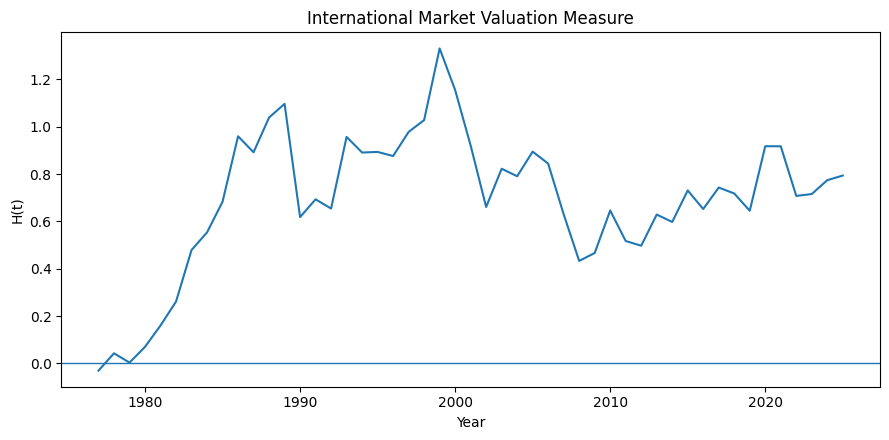

In [6]:
model_data["H"] = model_data["C"] - c_hat*model_data["t"]

plt.figure(figsize=(9, 4.5))
plt.plot(model_data["Year"], model_data["H"])
plt.axhline(0, linewidth=1)
plt.xlabel("Year")
plt.ylabel("H(t)")
plt.title("International Market Valuation Measure")
plt.tight_layout()
plt.show()

In [7]:
adf = adfuller(model_data["H"], regression="c", autolag="AIC")

print("ADF statistic:", round(adf[0], 4))
print("ADF p-value:", round(adf[1], 4))
print("5% critical value:", round(adf[4]["5%"], 4))

ADF statistic: -2.7818
ADF p-value: 0.0609
5% critical value: -2.924


## 6. Confidence interval for $c$

Since $c=\beta/\gamma$, the interval uses the joint estimated covariance of $\widehat{\beta}$ and $\widehat{\gamma}$.

In [8]:
cov = fit.cov_params()
cov_bg = np.array([
    [cov.loc["t", "t"], -cov.loc["t", "C_lag"]],
    [-cov.loc["C_lag", "t"], cov.loc["C_lag", "C_lag"]]
])

rng = np.random.default_rng(2026)
draws = rng.multivariate_normal([beta, gamma], cov_bg, size=100000)
c_sim = draws[:, 0] / draws[:, 1]
ci_low, ci_high = np.quantile(c_sim, [0.025, 0.975])

print("95% CI for c:", (round(100*ci_low, 2), round(100*ci_high, 2)), "%")

95% CI for c: (np.float64(-3.05), np.float64(3.85)) %


## 7. Residual diagnostics

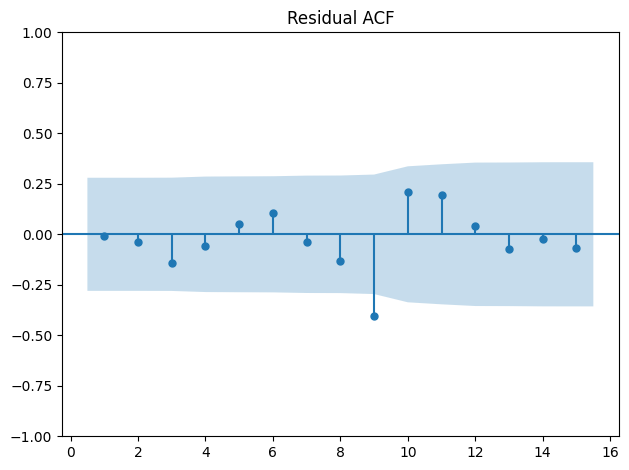

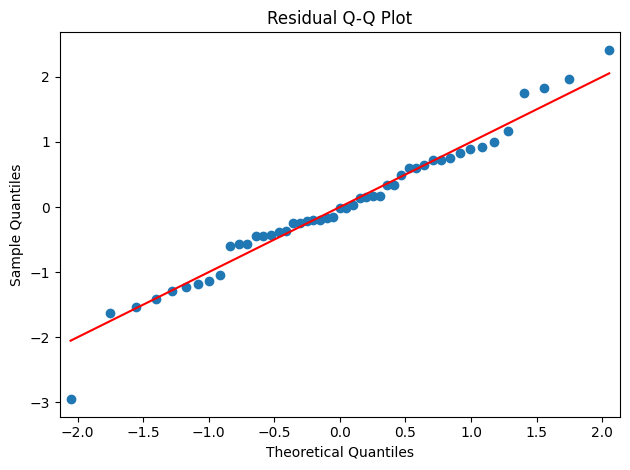

In [9]:
resid = fit.resid

plot_acf(resid, lags=15, zero=False)
plt.title("Residual ACF")
plt.tight_layout()
plt.show()

sm.qqplot(resid, line="s", fit=True)
plt.title("Residual Q-Q Plot")
plt.tight_layout()
plt.show()

In [10]:
sw = shapiro(resid)
lb = acorr_ljungbox(resid, lags=[5, 10], return_df=True)
lb2 = acorr_ljungbox(resid**2, lags=[5, 10], return_df=True)

print("Shapiro-Wilk p-value:", round(sw.pvalue, 4))
print("Ljung-Box for Z")
print(lb.round(4))
print()
print("Ljung-Box for Z^2")
print(lb2.round(4))

Shapiro-Wilk p-value: 0.5944
Ljung-Box for Z
    lb_stat  lb_pvalue
5    1.4886     0.9144
10  16.4354     0.0878

Ljung-Box for Z^2
    lb_stat  lb_pvalue
5    3.8206     0.5755
10  14.2934     0.1600


## 8. Individual countries

In [11]:
def annual_mkt(path):
    lines = Path(path).read_text(errors="ignore").splitlines()
    starts = [i for i, line in enumerate(lines)
              if "Value-Weight Dollar Returns" in line]

    for start in starts:
        rows = []
        for line in lines[start + 1:]:
            match = re.match(r"^\s*(\d{4})\s+(-?\d+(?:\.\d+)?)", line)
            if match:
                rows.append((int(match.group(1)), float(match.group(2))))
            elif rows and line.strip() == "":
                break
        if len(rows) >= 5:
            return pd.DataFrame(rows, columns=["Year", "Mkt"])

In [12]:
def prepare_country(year, price, total):
    df = pd.DataFrame({"Year": year, "P": price/100, "T": total/100})
    df = df.sort_values("Year").reset_index(drop=True)

    df["S_prev"] = np.r_[1.0, np.cumprod(1 + df["P"].to_numpy())[:-1]]
    df["S"] = df["S_prev"] * (1 + df["P"])
    df["D"] = df["S_prev"] * (df["T"] - df["P"])

    if (df["D"] <= 0).any():
        return None

    df["Q"] = np.log(df["S"] + df["D"]) - np.log(df["S_prev"])
    df["G"] = np.log(df["D"]) - np.log(df["D"].shift(1))
    df["Y"] = df["Q"] - df["G"]
    m = df.dropna(subset=["Y"]).copy()
    m["C"] = m["Y"].cumsum()
    m["C_lag"] = m["C"].shift(1)
    m = m.dropna(subset=["C_lag"]).copy()
    m["t"] = np.arange(1, len(m) + 1)
    return m

In [13]:
def fit_country(m):
    fit = sm.OLS(m["Y"], sm.add_constant(m[["t", "C_lag"]])).fit()
    beta = fit.params["t"]
    gamma = -fit.params["C_lag"]
    b = 1 - gamma
    c = beta / gamma

    m["H"] = m["C"] - c*m["t"]
    adf_p = adfuller(m["H"], regression="c", autolag="AIC")[1]
    resid = fit.resid
    lb = acorr_ljungbox(resid, lags=[5, 10], return_df=True)
    lb2 = acorr_ljungbox(resid**2, lags=[5, 10], return_df=True)

    cov = fit.cov_params()
    cov_bg = np.array([[cov.loc["t","t"], -cov.loc["t","C_lag"]],
                       [-cov.loc["C_lag","t"], cov.loc["C_lag","C_lag"]]])
    draws = np.random.default_rng(2026).multivariate_normal(
        [beta, gamma], cov_bg, 100000)
    low, high = np.quantile(draws[:,0]/draws[:,1], [0.025, 0.975])
    return c, low, high, b, adf_p, shapiro(resid).pvalue, lb, lb2

In [14]:
country_files = {
    "Australia":"Austrlia", "Austria":"Austria", "Belgium":"Belgium",
    "Canada":"Canada", "Denmark":"Denmark", "Finland":"Finland",
    "France":"France", "Germany":"Germany", "Hong Kong":"HongKong",
    "Ireland":"Ireland", "Italy":"Italy", "Japan":"Japan",
    "Malaysia":"Malaysia", "Netherlands":"Nethrlnd", "New Zealand":"NewZland",
    "Norway":"Norway", "Singapore":"Singapor", "Spain":"Spain",
    "Sweden":"Sweden", "Switzerland":"Swtzrlnd", "United Kingdom":"UK"
}

results = []

In [15]:
for country, filename in country_files.items():
    p = annual_mkt(ROOT / "countries_price" / f"{filename}.Dat")
    t = annual_mkt(ROOT / "countries_total" / f"{filename}.Dat")
    joined = p.merge(t, on="Year", suffixes=("_price", "_total"))

    m = prepare_country(joined["Year"].to_numpy(),
                        joined["Mkt_price"].to_numpy(),
                        joined["Mkt_total"].to_numpy())

    if country == "Malaysia" or m is None:
        continue

    c0, lo, hi, b0, adf0, sw0, lb0, lb20 = fit_country(m)
    results.append([country, m["Year"].min(), m["Year"].max(), len(m),
                    c0, lo, hi, b0, adf0, sw0,
                    lb0.loc[5,"lb_pvalue"], lb0.loc[10,"lb_pvalue"],
                    lb20.loc[5,"lb_pvalue"], lb20.loc[10,"lb_pvalue"]])

## 9. Country comparison

In [16]:
columns = ["Country","Start","End","n","c","low","high","b","ADF p",
           "Shapiro p","LB(5) p","LB(10) p","LB2(5) p","LB2(10) p"]

summary = pd.DataFrame(results, columns=columns)
summary = summary.sort_values("Country").reset_index(drop=True)
summary.to_csv("country_summary.csv", index=False)

table = summary.copy()
for col in ["c", "low", "high"]:
    table[col] *= 100

table = table.rename(columns={"c":"c (%)", "low":"CI low", "high":"CI high"})
table.round(3)

,Country,Start,End,n,c (%),CI low,CI high,b,ADF p,Shapiro p,LB(5) p,LB(10) p,LB2(5) p,LB2(10) p
0,Australia,1977,2025,49,3.917,3.237,4.577,0.497,0.001,0.596,0.959,0.412,0.658,0.462
1,Austria,1989,2025,37,-1.172,-2.531,0.009,0.348,0.002,0.039,0.713,0.402,0.715,0.883
2,Belgium,1977,2025,49,4.343,-22.173,26.357,0.899,0.142,0.267,0.467,0.570,0.738,0.653
3,Canada,1979,2025,47,1.895,-4.264,4.655,0.852,0.289,0.204,0.479,0.033,0.829,0.005
4,Denmark,1991,2025,35,0.029,-0.947,1.014,0.043,0.000,0.261,0.489,0.360,0.273,0.663
5,Finland,1990,2025,36,-0.455,-5.491,3.387,0.665,0.021,0.082,0.149,0.021,0.990,0.751
6,France,1977,2025,49,3.574,-0.763,5.779,0.770,0.035,0.647,0.588,0.387,0.665,0.229
7,Germany,1977,2025,49,3.658,0.867,5.916,0.758,0.094,0.807,0.504,0.834,0.727,0.871
8,Hong Kong,1977,2025,49,3.728,2.774,4.618,0.444,0.001,0.093,0.520,0.288,0.992,0.999
9,Ireland,1993,2025,33,1.704,-4.864,4.665,0.605,0.122,0.367,0.982,0.645,0.291,0.207


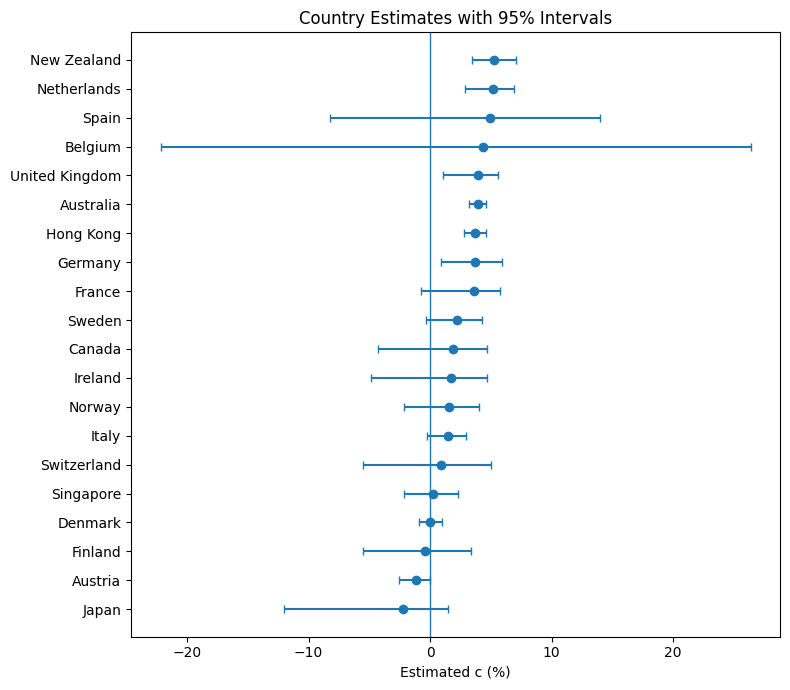

In [17]:
plot_data = summary.sort_values("c")
x = 100*plot_data["c"]
low = 100*plot_data["low"]
high = 100*plot_data["high"]

plt.figure(figsize=(8, 7))
plt.errorbar(x, plot_data["Country"],
             xerr=np.vstack([x-low, high-x]), fmt="o", capsize=3)
plt.axvline(0, linewidth=1)
plt.xlabel("Estimated c (%)")
plt.title("Country Estimates with 95% Intervals")
plt.tight_layout()
plt.show()

Malaysia is omitted because the available annual series contains a zero implied dividend, making $\log(D_t)$ undefined.